A note book for documenting qualitative results

In [1]:
import os
import matplotlib.pyplot as plt
import torchvision
import torch
import pandas as pd
import numpy as np
import data_loaders
from torchvision import transforms
import torch
import utils


In [2]:
#import the dataset

majority_config = {'CUB_dir':r'CUB_200_2011',
                'split_file':r'CUB_200_2011/train_test_split.txt',
                'use_majority_voting':True,
                'min_class_count':10,
                'return_visibility':False}

#Center crop the image to 299x299 for Inception V3 and convert to tensor but do not normalize
transform = transforms.Compose([
    transforms.CenterCrop(299),
    transforms.ToTensor(), #implicitly divides by 255
    #transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])
    ])

dataset = data_loaders.CUB_dataset(config_dict=majority_config, mode='test', transform=transform)

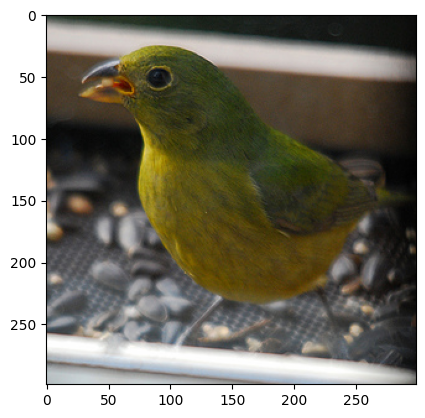

In [3]:

id = 391

x, c, y, cordinates = dataset[id]

#Visualize the image
plt.imshow(x.permute(1,2,0))




In [4]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'Models/ConceptModel__Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Models/IndependentModel_WithVal___Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

# Run prediction for the selected image

x_batch = x.unsqueeze(0)
concept_preds = torch.tensor(XtoC_Model(x_batch))

class_logits = CtoY_Model(concept_preds)
pred_class_idx = torch.argmax(class_logits).item()
pred_confidence = torch.softmax(class_logits,dim=0)[pred_class_idx].item()

# Display scrollable concept comparison table
df = utils.print_prediction(dataset, id, concept_preds, pred_class_idx, pred_confidence,mispredict_class_idx=True)

/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.batchnorm.BatchNorm2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has ch

Image index: 391  (img_id: 882)
True class:      15 - 016.Painted_Bunting
Predicted class: 172 - 173.Orange_crowned_Warbler  (confidence: 1.000)
Concept accuracy (majority voting): 101/112
Concept accuracy (original): 92/112
Labels differ (original vs majority voting): 17/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),173.Orange_crowned_Warbler (majority voting),Vote Differs
0,has_bill_shape::dagger,-9.912,False,False,False,False,False
1,has_bill_shape::hooked_seabird,-9.189,False,False,False,False,False
2,has_bill_shape::all-purpose,3.356,True,False,False,True,False
3,has_bill_shape::cone,-2.989,False,True,True,False,False
4,has_wing_color::brown,-7.695,False,False,False,False,False
5,has_wing_color::grey,-3.722,False,False,False,False,False
6,has_wing_color::yellow,-3.690,False,True,False,False,True
7,has_wing_color::black,-3.425,False,False,False,False,False
8,has_wing_color::white,-4.157,False,False,False,False,False
9,has_wing_color::buff,-9.659,False,False,False,False,False


In [5]:
#Make concept dictionary
"""
concept_prediction = concept_prediction[0].detach()
concepts_propebability = torch.sigmoid(concept_prediction)
pridicted_class = Majority_dataset.concepts[Y]
#Apply mask
if concept_prediction.shape != Majority_C.shape:
    concept_prediction = concept_prediction[mask]
    concepts_propebability = concepts_propebability[mask]
"""


#Get ture labels 
_,NoN_Majority_C,_,_ = Non_majority_data_set.__getitem__(picturer_idx)
Majority_C,_ = Majority_dataset.__getitem__(picturer_idx)

#Find distribution of the concepts
Majority_concepts = Majority_dataset.concepts
NoN_Majority_concepts = np.array([Non_majority_data_set.concepts[y] for y in Non_majority_data_set.concepts.keys()])


Concept_dict={"Concept":concept_names,
                    "Label": NoN_Majority_C[mask].numpy().astype(bool),
                    #"Label distribution": np.mean(NoN_Majority_concepts,axis=0)[mask],
                    "Majority Label": Majority_C.numpy().astype(bool),
                    #"Majority ditribution": np.mean(Majority_concepts,axis=0)
                      }
    


  

NameError: name 'Non_majority_data_set' is not defined

In [ ]:
#Test NoN majority joint model
model_path = r'evaluate_models\Joint_CKPT_NoMajority\best_Joint_model.pth'

#Load the model
Joint_model = torch.load(model_path,map_location=torch.device('cpu'),weights_only=False)
Joint_model.eval()
Joint_model.use_sigmoid = True

#Make prediction
C_hat,Y_hat = Joint_model(X)
C_hat_probability = torch.sigmoid(C_hat)
Y_hat = torch.softmax(Y_hat,dim=1)
print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = Joint_model.CtoY_model.linear.weight[Y.argmax().item()]
Concept_dict["Joint NoN-MV"] = np.round(C_hat_probability.detach().numpy()[0][mask],2)
#display_scrollable_dataframe(pd.DataFrame(Concept_dict).sort_values(by=['Joint NonMajority prediction'],ascending=False))

Predicted class: 173.Orange_crowned_Warbler true class: 016.Painted_Bunting probability of true class: 0.010831981897354126


In [ ]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'models\Sequential_CKTP_NoPretraining\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'models\Sequential_CKTP_NoPretraining\best_CtoY_model.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

#Make prediction
C_hat = XtoC_Model(X)
C_hat_probability = torch.sigmoid(C_hat)

Y_hat = torch.softmax(CtoY_Model(C_hat_probability),dim=1)

print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = CtoY_Model.linear.weight[Y.argmax().item()]

Concept_dict["Sequential No Pretraining"] = np.round(C_hat_probability.detach().numpy()[0],2)
#display_scrollable_dataframe(pd.DataFrame(Concept_dict).sort_values(by=['Majority Label',"Label"],ascending=False))





Predicted class: 168.Kentucky_Warbler true class: 016.Painted_Bunting probability of true class: 8.131758206251019e-14


In [ ]:
# Test the concept model with NoN majority voting
XtoC_Model = torch.load(r'evaluate_models\Concepts_CKPT_NoMajority\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'evaluate_models\Sequntial_NoMajority_end\best_CtoY_model.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

#Make prediction
C_hat = XtoC_Model(X)
C_hat_probability = torch.sigmoid(C_hat)

Y_hat = torch.softmax(CtoY_Model(C_hat_probability),dim=1)

print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = CtoY_Model.linear.weight[Y.argmax().item()]

Concept_dict["Sequential"] = np.round(C_hat_probability.detach().numpy()[0][mask],2)

Predicted class: 173.Orange_crowned_Warbler true class: 016.Painted_Bunting probability of true class: 1.8601131159812212e-06


In [ ]:
# Test the concept model with NoN majority voting
XtoC_Model = torch.load(r'models\Sequential_CKTP_resize\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'models\Sequential_CKTP_resize\best_CtoY_model.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

#Make prediction
C_hat = XtoC_Model(X)
C_hat_probability = torch.sigmoid(C_hat)

Y_hat = torch.softmax(CtoY_Model(C_hat_probability),dim=1)

print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = CtoY_Model.linear.weight[Y.argmax().item()]

Concept_dict["Sequential Rezise"] = np.round(C_hat_probability.detach().numpy()[0][mask],2)
#display_scrollable_dataframe(pd.DataFrame(Concept_dict).sort_values(by=['Majority Label',"Label"],ascending=False))

Predicted class: 153.Philadelphia_Vireo true class: 016.Painted_Bunting probability of true class: 3.3368891649843135e-07


In [ ]:
#Add the baslines
Concept_dict["NoN-MV Label distribution"] = np.mean(NoN_Majority_concepts,axis=0)[mask]
Concept_dict["MV label ditribution"] = np.mean(Majority_concepts,axis=0)


In [ ]:
Full_df=pd.DataFrame(Concept_dict)
Selected_df = Full_df[Full_df["Majority Label"] != Full_df["Label"]]

# add row 39 to selected
#Selected_df = pd.concat([Selected_df,Full_df.iloc[[39,8,51]]])

display_scrollable_dataframe(Full_df.sort_values(by=['Majority Label',"Label"],ascending=False))

,Concept,Label,Majority Label,Joint NoN-MV,Sequential No Pretraining,Sequential,Sequential Rezise,NoN-MV Label distribution,MV label ditribution
7,has_bill_shape::cone,True,True,0.23,0.15,0.18,0.26,0.261452,0.245
145,has_eye_color::black,True,True,0.89,0.85,0.93,0.94,0.837462,0.960
151,has_bill_length::shorter_than_head,True,True,0.85,0.53,0.81,0.79,0.561079,0.630
239,has_back_pattern::multi-colored,True,True,0.32,0.25,0.25,0.24,0.194774,0.070
268,has_leg_color::grey,True,True,0.29,0.25,0.31,0.24,0.255599,0.225
283,has_bill_color::grey,True,True,0.53,0.34,0.64,0.35,0.273583,0.125
311,has_wing_pattern::multi-colored,True,True,0.27,0.27,0.33,0.29,0.297336,0.220
52,has_underparts_color::red,False,True,0.01,0.01,0.00,0.00,0.037156,0.030
54,has_breast_pattern::solid,False,True,0.61,0.26,0.63,0.66,0.548269,0.645
75,has_tail_shape::notched_tail,False,True,0.34,0.25,0.35,0.46,0.297506,0.290


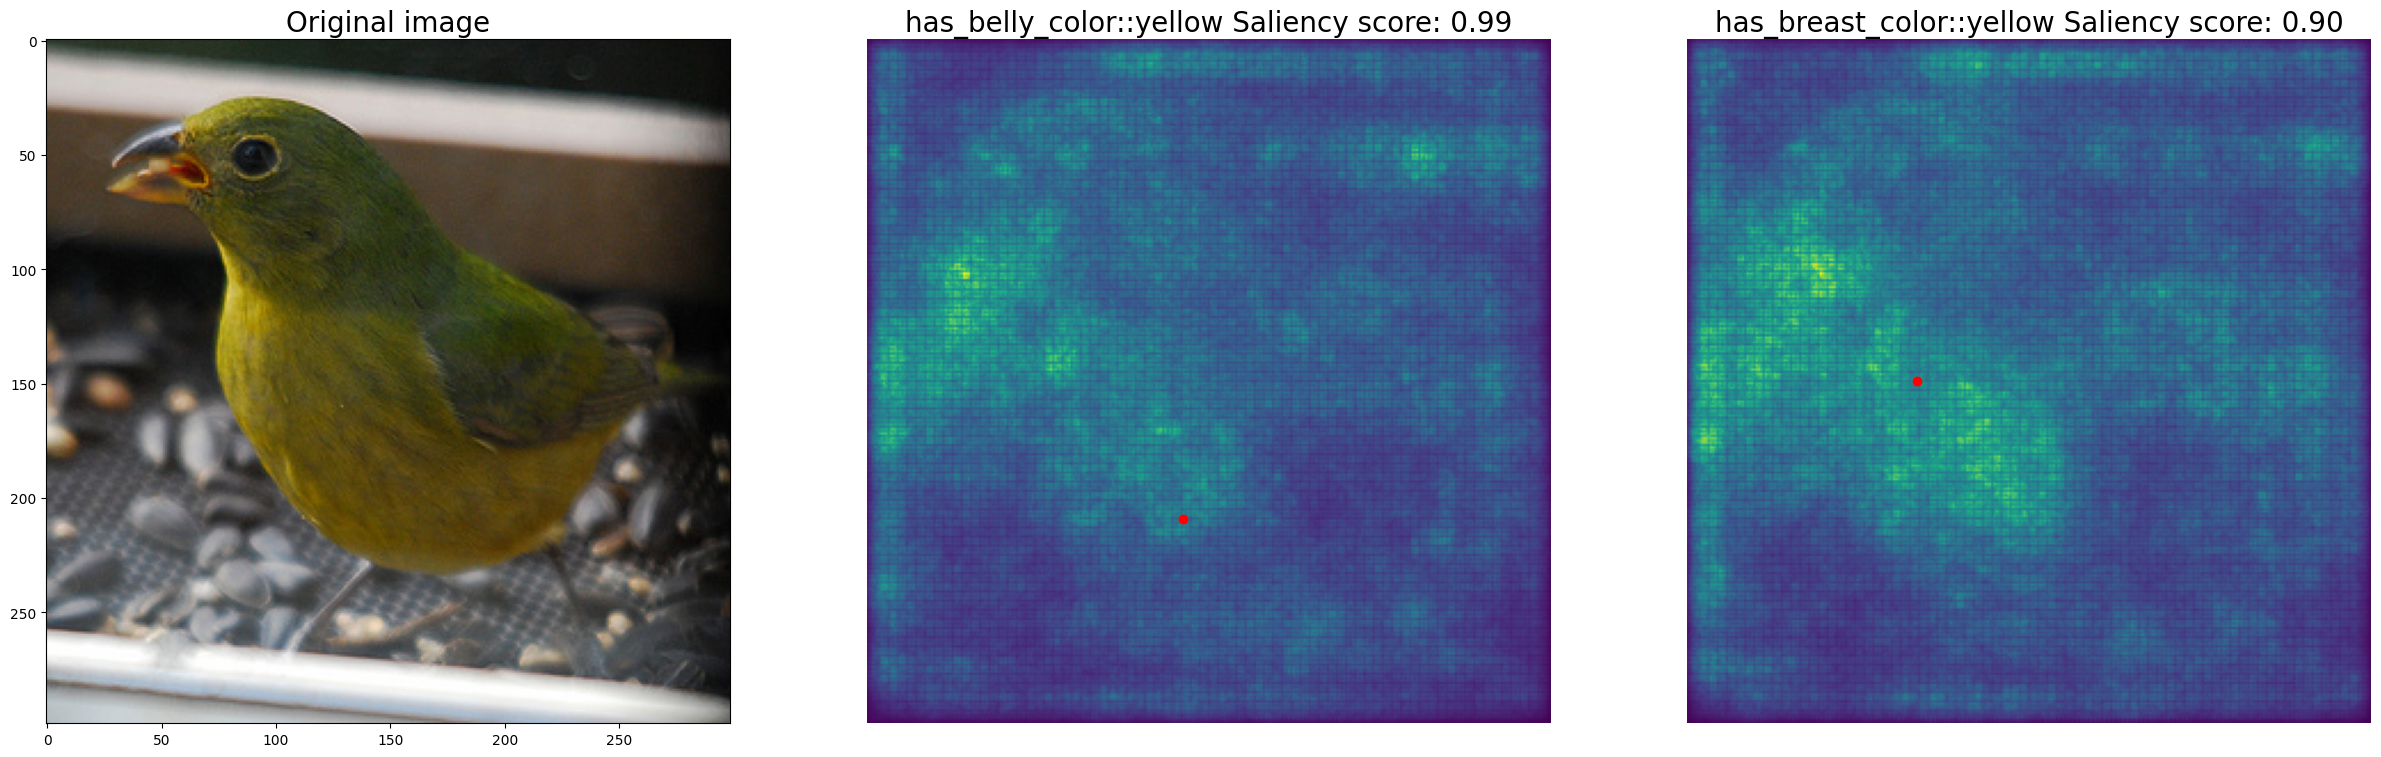

In [ ]:
concept_list = [203,111]
XtoC_Model = torch.load(r"evaluate_models\Concepts_CKPT_NoMajority\best_XtoC_model.pth",map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()
sailency_maps = get_saliency_maps(X,concept_list,XtoC_Model,method_type='noise_tunnel')

plot_sailency(img,sailency_maps,concept_list,concept_names,coordinates)

0.14244209


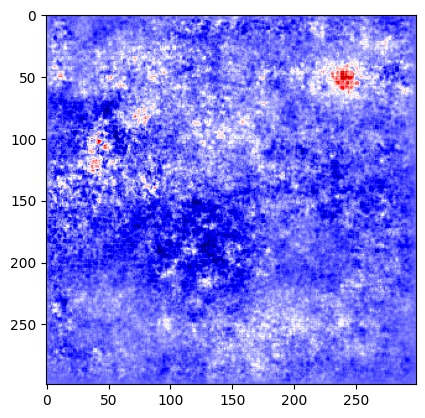

In [ ]:
s=sailency_maps[0]-sailency_maps[1]
print(np.abs(s).sum())
plt.imshow(s,cmap='seismic')

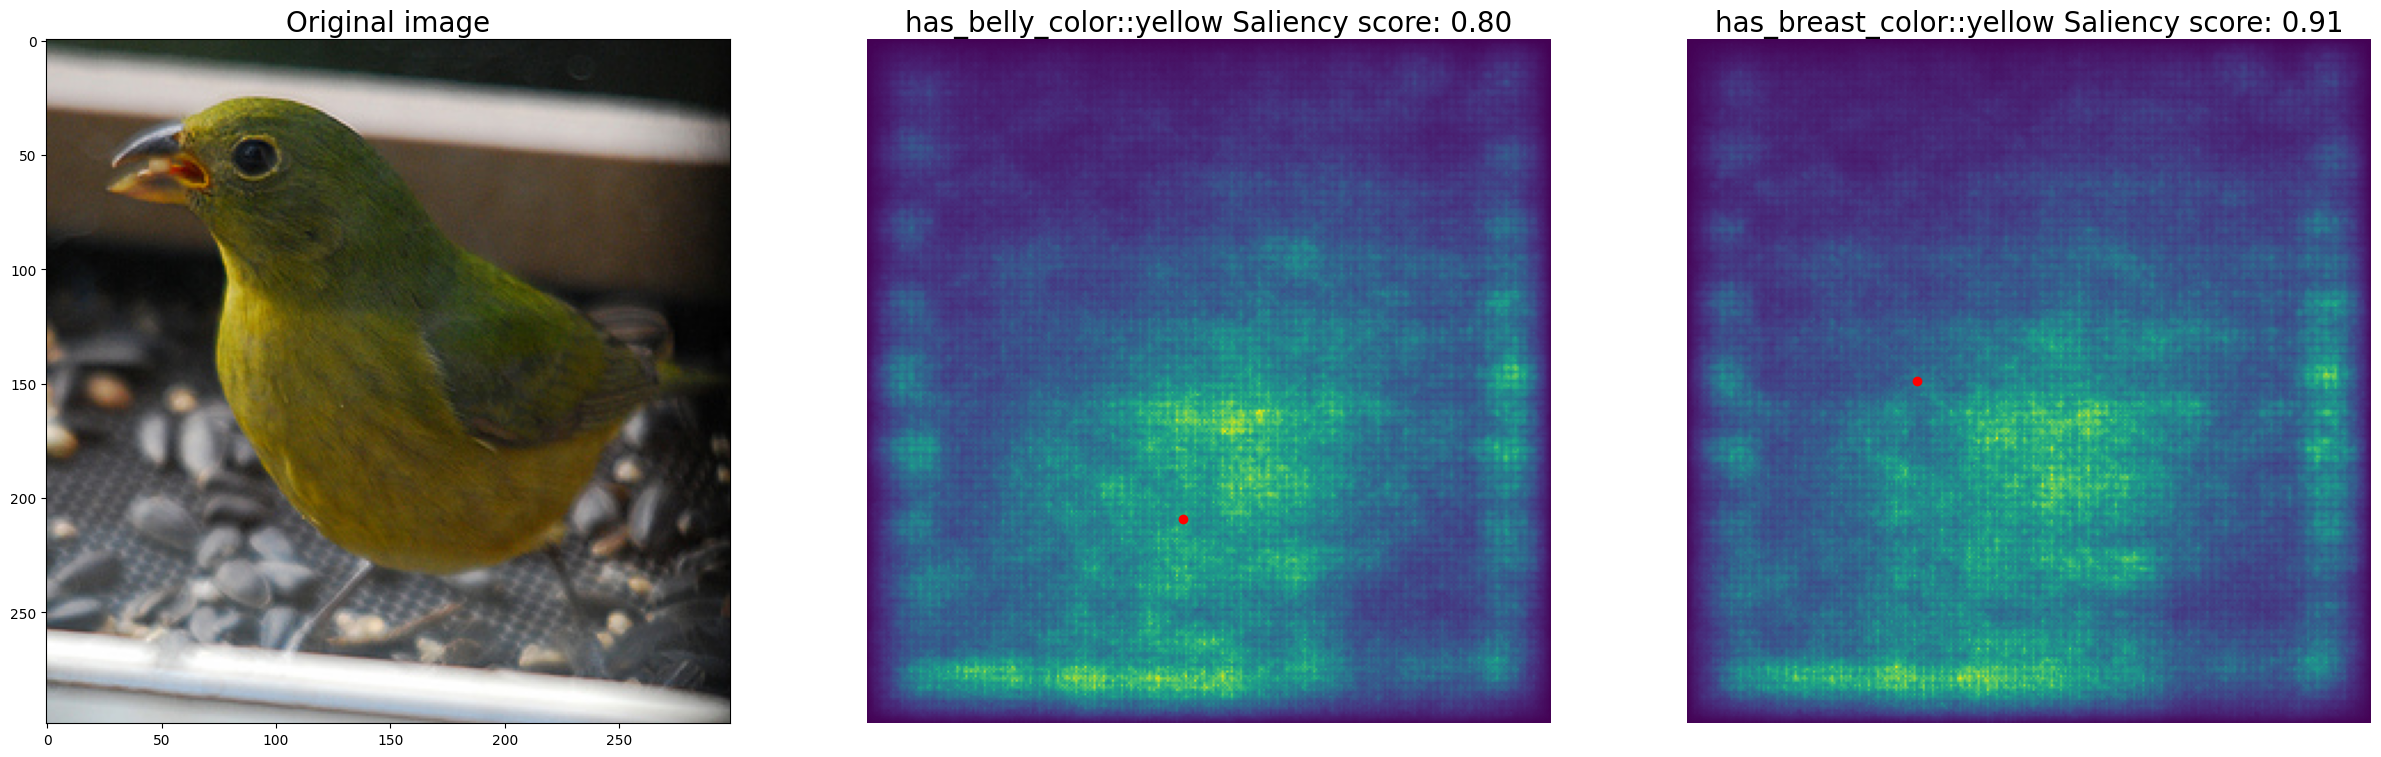

In [ ]:
#concept_list = [39,8,51]
XtoC_Model = torch.load(r'models\Sequential_CKTP_resize\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()
sailency_maps = get_saliency_maps(X,concept_list,XtoC_Model,method_type='noise_tunnel')

plot_sailency(img,sailency_maps,concept_list,concept_names,coordinates)

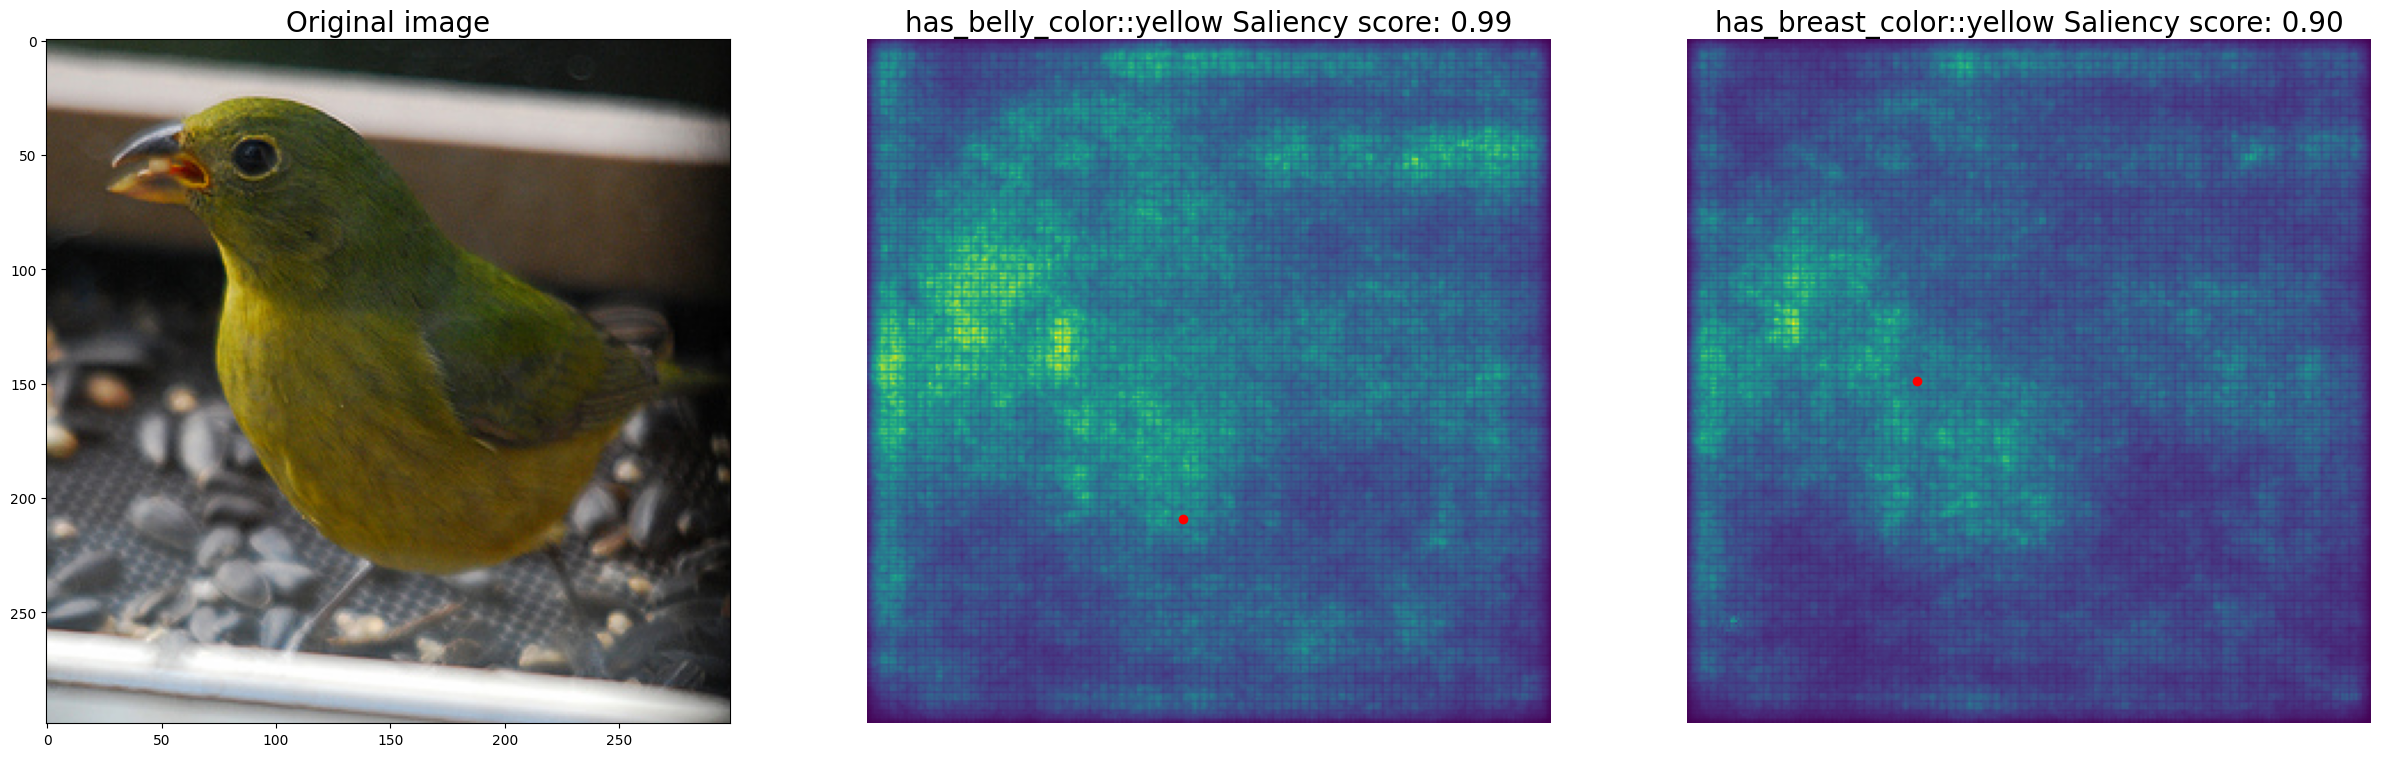

In [ ]:
XtoC_Model = torch.load(r'evaluate_models\Concepts_CKPT_NoMajority\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()
sailency_maps = get_saliency_maps(X,concept_list,XtoC_Model,method_type='noise_tunnel')

plot_sailency(img,sailency_maps,concept_list,concept_names,coordinates)

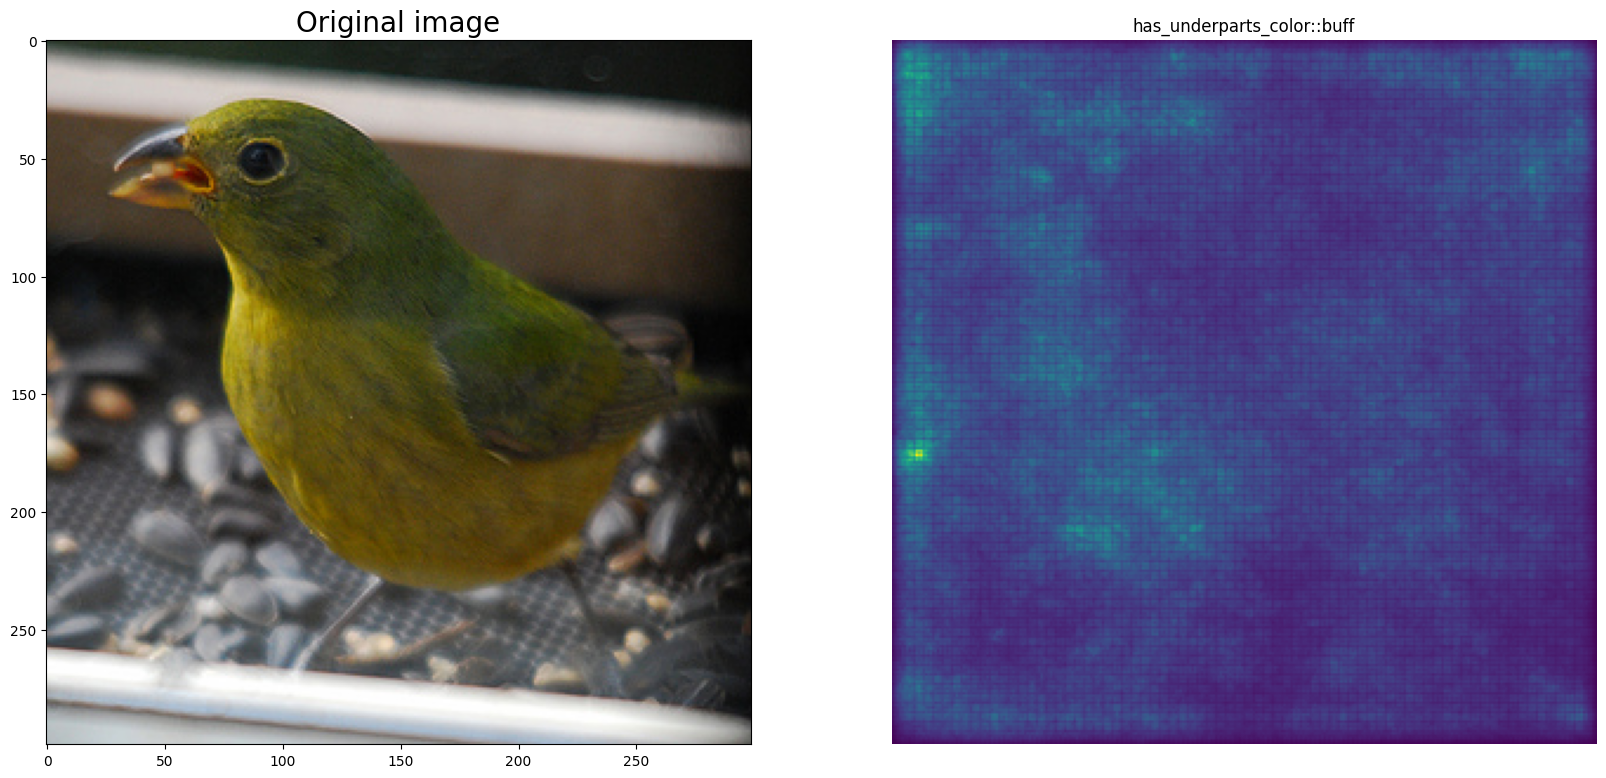

In [ ]:
concept_list = [53]
XtoC_Model = torch.load(r'evaluate_models\Concepts_CKPT_NoMajority\best_XtoC_model.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()
sailency_maps = get_saliency_maps(X,concept_list,XtoC_Model,method_type='noise_tunnel')

plot_sailency(img,sailency_maps,concept_list,concept_names,coordinates)

In [ ]:
#print full df
display_scrollable_dataframe(Full_df.sort_values(by=['Joint NoN-MV','Sequential'],ascending=False))

,Concept,Label,Majority Label,Joint NoN-MV,Sequential No Pretraining,Sequential,Sequential Rezise,NoN-MV Label distribution,MV label ditribution
145,has_eye_color::black,True,True,0.89,0.85,0.93,0.94,0.837462,0.960
17,has_wing_color::green,False,False,0.88,0.05,0.14,0.14,0.017645,0.015
190,has_nape_color::green,False,False,0.87,0.08,0.14,0.09,0.013573,0.005
151,has_bill_length::shorter_than_head,True,True,0.85,0.53,0.81,0.79,0.561079,0.630
126,has_throat_color::yellow,True,False,0.82,0.45,0.78,0.92,0.112572,0.105
111,has_breast_color::yellow,True,False,0.79,0.83,0.83,0.95,0.136834,0.145
32,has_upperparts_color::green,False,False,0.78,0.06,0.13,0.11,0.019002,0.010
160,has_forehead_color::green,False,False,0.78,0.02,0.11,0.04,0.009077,0.000
66,has_back_color::green,False,False,0.76,0.09,0.11,0.10,0.015439,0.010
45,has_underparts_color::yellow,True,False,0.70,0.89,0.83,0.97,0.149474,0.140


In [ ]:
print(Selected_df.to_latex(index=False))

\begin{tabular}{lrrrrrrrr}
\toprule
Concept & Label & Majority Label & Joint NoN-MV & Sequential No Pretraining & Sequential & Sequential Rezise & NoN-MV Label distribution & MV label ditribution \\
\midrule
has_wing_color::yellow & True & False & 0.150000 & 0.460000 & 0.330000 & 0.650000 & 0.091703 & 0.060000 \\
has_wing_color::olive & True & False & 0.210000 & 0.140000 & 0.480000 & 0.240000 & 0.038683 & 0.015000 \\
has_upperparts_color::yellow & True & False & 0.230000 & 0.500000 & 0.430000 & 0.670000 & 0.094503 & 0.080000 \\
has_upperparts_color::olive & True & False & 0.220000 & 0.140000 & 0.530000 & 0.290000 & 0.040210 & 0.015000 \\
has_underparts_color::yellow & True & False & 0.700000 & 0.890000 & 0.830000 & 0.970000 & 0.149474 & 0.140000 \\
has_underparts_color::olive & True & False & 0.170000 & 0.030000 & 0.290000 & 0.100000 & 0.022735 & 0.005000 \\
has_underparts_color::red & False & True & 0.010000 & 0.010000 & 0.000000 & 0.000000 & 0.037156 & 0.030000 \\
has_breast_pattern:

In [ ]:
display_scrollable_dataframe(Full_df.sort_values(by=['Majority Label',"Label"],ascending=False))

,Concept,Label,Majority Label,Joint NoN-MV,Sequential No Pretraining,Sequential,Sequential Rezise,NoN-MV Label distribution,MV label ditribution
7,has_bill_shape::cone,True,True,0.23,0.15,0.18,0.26,0.261452,0.245
145,has_eye_color::black,True,True,0.89,0.85,0.93,0.94,0.837462,0.960
151,has_bill_length::shorter_than_head,True,True,0.85,0.53,0.81,0.79,0.561079,0.630
239,has_back_pattern::multi-colored,True,True,0.32,0.25,0.25,0.24,0.194774,0.070
268,has_leg_color::grey,True,True,0.29,0.25,0.31,0.24,0.255599,0.225
283,has_bill_color::grey,True,True,0.53,0.34,0.64,0.35,0.273583,0.125
311,has_wing_pattern::multi-colored,True,True,0.27,0.27,0.33,0.29,0.297336,0.220
52,has_underparts_color::red,False,True,0.01,0.01,0.00,0.00,0.037156,0.030
54,has_breast_pattern::solid,False,True,0.61,0.26,0.63,0.66,0.548269,0.645
75,has_tail_shape::notched_tail,False,True,0.34,0.25,0.35,0.46,0.297506,0.290


In [ ]:
df=pd.DataFrame(Concept_dict).sort_values(by=['Majority Label',"Label"],ascending=False)
latex_table = df.to_latex(index=False)
print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
Concept & Label & Majority Label & Joint NoN-MV & Sequential No Pretraining & Sequential & Sequential Rezise & NoN-MV Label distribution & MV label ditribution \\
\midrule
has_bill_shape::cone & True & True & 0.230000 & 0.150000 & 0.180000 & 0.260000 & 0.261452 & 0.245000 \\
has_eye_color::black & True & True & 0.890000 & 0.850000 & 0.930000 & 0.940000 & 0.837462 & 0.960000 \\
has_bill_length::shorter_than_head & True & True & 0.850000 & 0.530000 & 0.810000 & 0.790000 & 0.561079 & 0.630000 \\
has_back_pattern::multi-colored & True & True & 0.320000 & 0.250000 & 0.250000 & 0.240000 & 0.194774 & 0.070000 \\
has_leg_color::grey & True & True & 0.290000 & 0.250000 & 0.310000 & 0.240000 & 0.255599 & 0.225000 \\
has_bill_color::grey & True & True & 0.530000 & 0.340000 & 0.640000 & 0.350000 & 0.273583 & 0.125000 \\
has_wing_pattern::multi-colored & True & True & 0.270000 & 0.270000 & 0.330000 & 0.290000 & 0.297336 & 0.220000 \\
has_underparts_color::red & F